In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import accuracy_score, classification_report

In [39]:
df = pd.read_csv("HR_Employee_Attrition.csv")

In [40]:
df.head()

,Employee_ID,Age,Gender,Department,JobRole,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,Female,Sales,Sales Executive,Yes,Travel_Rarely,1102,1,2,...,1,80,0,8,0,1,6,4,0,5
1,2,49,Male,Research & Development,Research Scientist,No,Travel_Frequently,279,8,1,...,4,80,1,10,3,3,10,7,1,7
2,4,37,Male,Research & Development,Laboratory Technician,Yes,Travel_Rarely,1373,2,2,...,2,80,0,7,3,3,0,0,0,0
3,5,33,Female,Research & Development,Research Scientist,No,Travel_Frequently,1392,3,4,...,3,80,0,8,3,3,8,7,3,0
4,7,27,Male,Research & Development,Laboratory Technician,No,Travel_Rarely,591,2,1,...,4,80,1,6,3,3,2,2,2,2


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee_ID               1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   Department                1470 non-null   object
 4   JobRole                   1470 non-null   object
 5   Attrition                 1470 non-null   object
 6   BusinessTravel            1470 non-null   object
 7   DailyRate                 1470 non-null   int64 
 8   DistanceFromHome          1470 non-null   int64 
 9   Education                 1470 non-null   int64 
 10  EducationField            1470 non-null   object
 11  EmployeeCount             1470 non-null   int64 
 12  EnvironmentSatisfaction   1470 non-null   int64 
 13  HourlyRate                1470 non-null   int64 
 14  JobInvolvement          

In [42]:
df.describe()

,Employee_ID,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,602.024335,9.135373,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,491.250000,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1020.500000,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1555.750000,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2068.000000,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


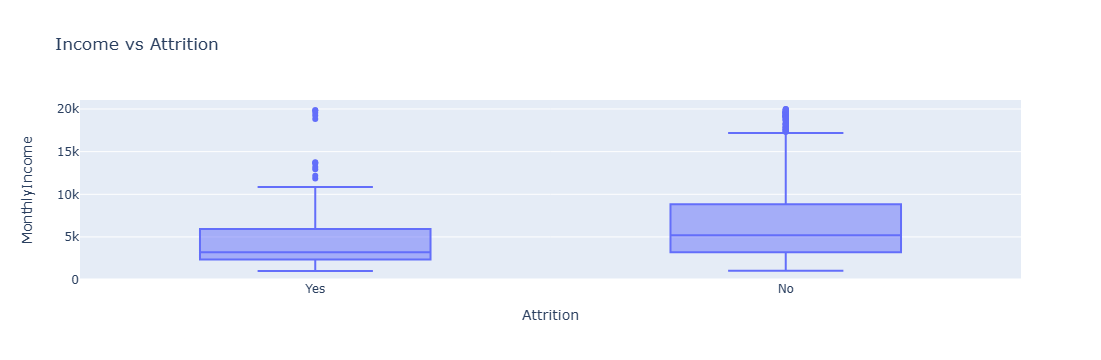

In [43]:
import plotly.express as px

fig = px.box(df, x='Attrition', y='MonthlyIncome', title="Income vs Attrition")
fig.show()

In [44]:
df.head()
df.shape

(1470, 34)

In [45]:
df.isnull().sum()

Employee_ID                 0
Age                         0
Gender                      0
Department                  0
JobRole                     0
Attrition                   0
BusinessTravel              0
DailyRate                   0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

In [46]:
list(df.columns)

['Employee_ID',
 'Age',
 'Gender',
 'Department',
 'JobRole',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [47]:
df["Attrition_Num"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [48]:
attrition_rate = df["Attrition_Num"].mean()
print(attrition_rate)

0.16122448979591836



# 7-Attrition Distribution


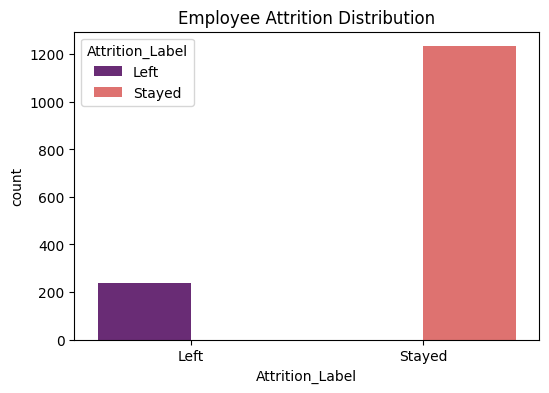

In [49]:
df["Attrition_Label"] = df["Attrition"].map({
    "No": "Stayed",
    "Yes": "Left"
})

plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition_Label",
    hue="Attrition_Label",
    data=df,
    palette="magma"
)

plt.title("Employee Attrition Distribution")
plt.show()


# 8-Attrition by Department


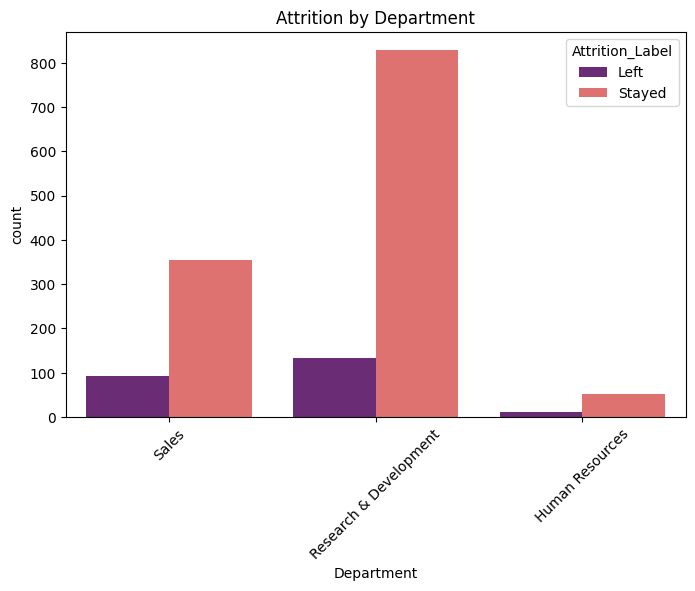

In [50]:
df["Attrition_Label"] = df["Attrition"].map({
    "No": "Stayed",
    "Yes": "Left"
})

plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition_Label",
    data=df,
    palette="magma"
)

plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

In [51]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [52]:
le = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

In [53]:
X = X.drop([
    'EmployeeCount',
    'StandardHours',
    'Employee_ID'
], axis=1)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

الخطوة القادمة بتتعمل بس لو الموديل مشتغلش بتأكد ان الداتا مفيهاش object

In [56]:
X_train.dtypes

Age                         int64
Gender                      int32
Department                  int32
JobRole                     int32
BusinessTravel              int32
DailyRate                   int64
DistanceFromHome            int64
Education                   int64
EducationField              int32
EnvironmentSatisfaction     int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobSatisfaction             int64
MaritalStatus               int32
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int32
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrM

In [57]:
for col in X_train.select_dtypes(include=['object']).columns:
    print(col)

In [58]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

بعد ما طلع الاوت بتاع السيل الى قبل دا كدا اصفار ف محتاج اتاكد هو كدا متحيز لحاجة معينه ولا هو كدا نتيجة صح؟ ف هعمل ال 3 خطوات الجايين

In [59]:
y_pred = model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00       255
         Yes       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294



(معلومة اضافيه ) أهم العوامل المؤثرة في الاستقالة

In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
30         Attrition_Num    0.474785
31       Attrition_Label    0.349603
18              OverTime    0.027604
15         MonthlyIncome    0.017061
23     TotalWorkingYears    0.013783
0                    Age    0.010192
22      StockOptionLevel    0.009877
26        YearsAtCompany    0.007793
29  YearsWithCurrManager    0.007384
12              JobLevel    0.007333


In [63]:
X = X.drop("Attrition_Label", axis=1)

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       255
         Yes       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294



In [68]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

              Feature  Importance
30      Attrition_Num    0.629841
18           OverTime    0.039362
15      MonthlyIncome    0.030893
0                 Age    0.022387
22   StockOptionLevel    0.020873
26     YearsAtCompany    0.018316
23  TotalWorkingYears    0.017195
12           JobLevel    0.017124
3             JobRole    0.016250
5           DailyRate    0.016151


In [69]:
y.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

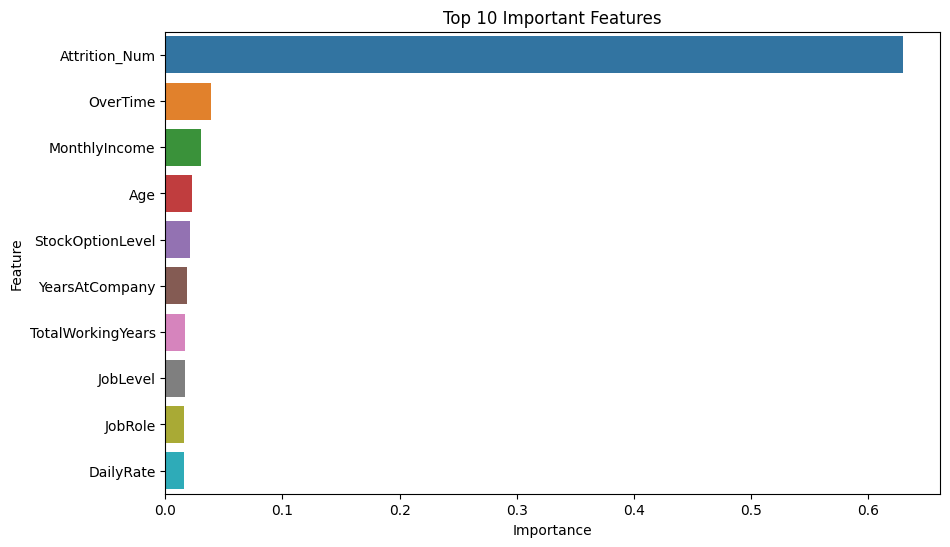

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

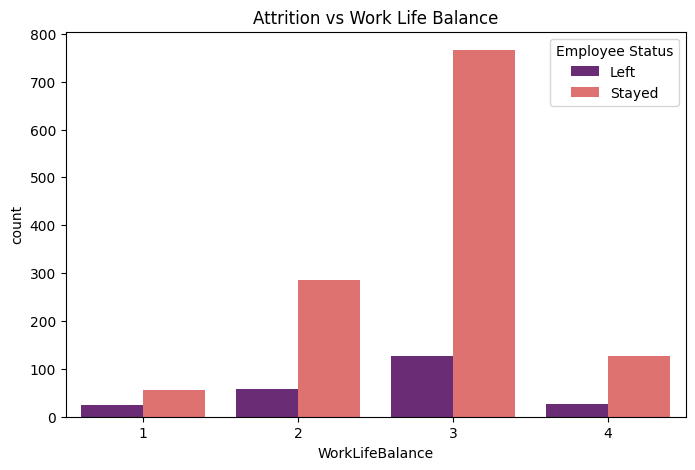

In [71]:
df["Attrition_Label"] = df["Attrition"].map({
    "No": "Stayed",
    "Yes": "Left"
})

plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition_Label",
    data=df,
    palette="magma"
)

plt.title("Attrition vs Work Life Balance")
plt.legend(title="Employee Status")
plt.show()

In [72]:
fig.show()

In [73]:
df.groupby("Attrition")["DistanceFromHome"].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64